# Targeting logic as a governance variable

### Two institutional routes to a heat-pump programme

The same heat pumps can be rolled out by different institutional actors, and who runs the
programme changes what it delivers. This notebook compares two routes at their realistic
reach, on demand and heating that come entirely from the v7 SERL-calibrated model.

| route | actor | mechanism | policy analogue |
|---|---|---|---|
| Council / social rent | local authority | owns the stock, can plan and install at scale | Social Housing Decarbonisation Fund |
| Provider / grants (wealthy) | energy supplier | voluntary grant uptake, skews to wealthy high-consumers | Boiler Upgrade Scheme |

The two routes isolate the targeting rule. The council route is deliverable, because it
owns the homes and needs no per-household consent, and it reaches lower-income tenants, but
social housing is smaller and better insulated so each home displaces less heat. The grant
route reaches large, high-consuming homes and so saves more per install, but uptake is
voluntary and slow, and the public money flows to households who could largely self-fund.
Targeting logic is the governance variable: it trades deliverability and distribution
against per-home energy impact.

Every input is calibrated, with no proxy fields. Per-home consumption and space heating
come from the v7 model's own full-Newcastle decomposition, the same config notebook 1
writes. Heat-pump COP is read from the field-data calibration in
[`heatpump_cop_calibration.ipynb`](heatpump_cop_calibration.ipynb): the conservative DESNZ
median is the headline, the well-installed field median the sensitivity. Converting a gas
home moves its space heat to electricity at `0.90 / COP`, about a third of the energy, and
from the gas meter to the electricity meter.

In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd, geopandas as gpd, yaml
import matplotlib.pyplot as plt

REPO = Path.cwd()
while not (REPO / "household_energy").exists() and REPO != REPO.parent:
    REPO = REPO.parent
os.chdir(REPO)
SCRIPTS = REPO / "research" / "applied" / "scripts"
sys.path.insert(0, str(REPO)); sys.path.insert(0, str(SCRIPTS))
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

# Dated run (latest by default, from notebook 1) to deposit the policy summary into.
import run_paths
RUN_DATE = None
RUN = run_paths.run_dir(RUN_DATE, create=True)

# Regenerate the full-city decomposition with run_city_decomp (~17 min, resumable) vs read
# the committed CSV. Off by default; turn on after a calibration change so the headline
# city totals reflect the new config rather than a stale decomposition.
RUN_CITY = False

# Reach differs by actor, which is the point. The council owns its social stock and can
# deliver it at scale; the grant route is throttled by voluntary owner-occupier uptake.
COUNCIL_HOMES   = None    # None = the council's whole eligible social-rent stock, or cap it
PROVIDER_UPTAKE = 0.20    # share of eligible wealthy owner-occupiers who take up a grant

# COP read from the field-data calibration (the COP notebook), not hardcoded.
cop = yaml.safe_load((REPO / "results" / "field_fits" / "heatpump_cop.yaml").read_text())
COP_HEAD, COP_SENS = cop["cop_representative"], cop["cop_field_median_space"]
BOILER_EFF = 0.90
HP_COST, HP_LIFETIME = 12000, 15
GAS_KGCO2, ELEC_KGCO2 = 0.183, 0.207   # BEIS 2023
hp_mult = {f"conservative (COP {COP_HEAD})": BOILER_EFF / COP_HEAD,
           f"well-installed (COP {COP_SENS})": BOILER_EFF / COP_SENS}
HEAD = f"conservative (COP {COP_HEAD})"
print("run:", RUN.relative_to(REPO))
print("COP from results/field_fits/heatpump_cop.yaml ->", COP_HEAD, "headline /", COP_SENS, "sensitivity")
print("HP heating multiplier (x gas space heat):", {k: round(v, 3) for k, v in hp_mult.items()})

run: results/runs/2026-06-24
COP from results/field_fits/heatpump_cop.yaml -> 2.8 headline / 4.21 sensitivity
HP heating multiplier (x gas space heat): {'conservative (COP 2.8)': 0.321, 'well-installed (COP 4.21)': 0.214}


## 1 · Study population: the model's own per-home demand

Per-home consumption and space heating come straight from the v7 calibrated model, the
full-city decomposition when it is present and the 30-LSOA validation sample otherwise.
Tenure and income come from the synthetic-population match. The eligible pool is the
gas-heated homes the model flags as heat-pump candidates.

In [2]:
city_csv = REPO / "results_lsoa" / "decomp_city_newcastle_2023_v7.csv"
samp_csv = REPO / "results_lsoa" / "decomp_sample_newcastle_2023_v7.csv"
N_NEWCASTLE_LSOA = 185

if RUN_CITY:
    # Resumable full-city decomposition under the latest config (the same EnergyModel and
    # decomposition notebook 3 uses); appends any missing LSOAs to city_csv.
    from run_city_decomp import main as run_city
    run_city()

DECOMP = samp_csv
if city_csv.exists():
    n_done = pd.read_csv(city_csv, usecols=["lsoa_code"]).lsoa_code.nunique()
    if n_done >= 0.95 * N_NEWCASTLE_LSOA:
        DECOMP = city_csv
    else:
        print(f"(full-city decomposition partial: {n_done}/{N_NEWCASTLE_LSOA}, using the 30-LSOA sample)")
dec = pd.read_csv(DECOMP); dec["unique_id"] = dec["unique_id"].astype(str)
dec["consumption_kwh"] = dec.electric_kwh + dec.gas_kwh
dec["gas_heat_kwh"] = dec.heat_kwh
print(f"decomposition: {'FULL CITY' if DECOMP == city_csv else '30-LSOA sample'}, {len(dec):,} dwellings")

g = gpd.read_file(REPO / "data" / "epc_abm_newcastle.geojson"); g["UPRN"] = g["UPRN"].astype(str).str.strip()
hidp = pd.read_csv(REPO / "data" / "hidp_uprn_matches_tiered.csv", low_memory=False)
hidp["uprn_chr"] = hidp["uprn_chr"].astype(str).str.strip(); hidp = hidp.drop_duplicates("uprn_chr")
g = g.merge(hidp[["uprn_chr", "hh_income_band", "tenure"]], left_on="UPRN", right_on="uprn_chr", how="left")
df = dec.merge(g[["UPRN", "sap_band_ord", "is_heatpump_candidate", "hh_income_band", "tenure"]],
               left_on="unique_id", right_on="UPRN", how="left")
elig = df[(df.heating_bucket == "gas") & (df.is_heatpump_candidate == 1)].copy()
elig["ten"] = elig.tenure.astype(str).str.lower()
print(f"eligible (gas-heated HP candidates): {len(elig):,}")
print("tenure mix:", elig.ten.value_counts().to_dict())

decomposition: FULL CITY, 97,714 dwellings


eligible (gas-heated HP candidates): 44,940
tenure mix: {'owner_occupied': 27929, 'social_rent': 9175, 'private_rent': 7119}


## 2 · The two routes at their realistic reach

The budgets are not equal, because the actors can deliver different numbers and that is the
point. The council converts its whole eligible social-rent stock, since it owns the homes
and can. The provider reaches only the share of eligible wealthy owner-occupiers who take
up a grant voluntarily, highest-consuming first.

In [3]:
sr      = elig.ten.eq("social_rent")
wealthy = elig.ten.eq("owner_occupied") & elig.hh_income_band.isin(["q4_high", "q5_highest"])
n_council  = int(sr.sum()) if COUNCIL_HOMES is None else min(COUNCIL_HOMES, int(sr.sum()))
n_provider = int(round(PROVIDER_UPTAKE * int(wealthy.sum())))
print(f"eligible pools: social-rent {int(sr.sum()):,} | wealthy owner-occupier {int(wealthy.sum()):,}")
print(f"reach: council does its whole stock = {n_council:,} homes | provider at {PROVIDER_UPTAKE:.0%} uptake = {n_provider:,} homes")

cohorts = {
    "Council / social rent":       elig[sr].consumption_kwh.nlargest(n_council).index,
    "Provider / grants (wealthy)": elig[wealthy].consumption_kwh.nlargest(n_provider).index,
}
for n, idx in cohorts.items():
    c = elig.loc[idx]
    print(f"{n:30s} n={len(c):,} | mean heat {c.gas_heat_kwh.mean():,.0f} kWh | "
          f"Q1/Q2 {100*c.hh_income_band.isin(['q1_lowest','q2_low']).mean():3.0f}% | EPC E-G {100*(c.sap_band_ord<=3).mean():3.0f}%")

eligible pools: social-rent 9,175 | wealthy owner-occupier 9,152
reach: council does its whole stock = 9,175 homes | provider at 20% uptake = 1,830 homes
Council / social rent          n=9,175 | mean heat 7,918 kWh | Q1/Q2  31% | EPC E-G   6%
Provider / grants (wealthy)    n=1,830 | mean heat 21,365 kWh | Q1/Q2   0% | EPC E-G  35%


## 3 · Change in energy use, by route

For each converted home, the gas space heat is removed and electricity is added at
`heat x 0.90 / COP`; the net saving is gas removed minus electricity added. The table
reports both COP anchors so the per-home and total effects can be read at the conservative
headline and the well-installed sensitivity.

In [4]:
def impact(idx, mult):
    c = elig.loc[idx]; gas_saved = c.gas_heat_kwh.sum(); elec_added = (c.gas_heat_kwh * mult).sum()
    q12 = c.hh_income_band.isin(["q1_lowest", "q2_low"])
    return dict(homes=len(c), gas_saved_GWh=gas_saved/1e6, elec_added_GWh=elec_added/1e6,
                net_GWh=(gas_saved-elec_added)/1e6, per_home_net_kwh=(gas_saved-elec_added)/max(len(c), 1),
                q12_savings_share=c.gas_heat_kwh[q12].sum()/max(c.gas_heat_kwh.sum(), 1e-9),
                cost_per_GWh=len(c)*HP_COST/1e6/max((gas_saved-elec_added)/1e6, 1e-9))
res = pd.DataFrame([{**impact(idx, m), "route": n, "COP": cop_label}
                    for n, idx in cohorts.items() for cop_label, m in hp_mult.items()])
print(res[["route", "COP", "gas_saved_GWh", "elec_added_GWh", "net_GWh",
           "per_home_net_kwh", "q12_savings_share", "cost_per_GWh"]].round(2).to_string(index=False))

# Freeze the route impacts into the dated run snapshot, noting which decomposition fed them.
res["decomp"] = "full_city" if DECOMP == city_csv else "30lsoa_sample"
res.round(3).to_csv(RUN / "policy_route_impacts.csv", index=False)
print("\ndeposited ->", (RUN / "policy_route_impacts.csv").relative_to(REPO))

                      route                       COP  gas_saved_GWh  elec_added_GWh  net_GWh  per_home_net_kwh  q12_savings_share  cost_per_GWh
      Council / social rent    conservative (COP 2.8)          72.64           23.35    49.29           5372.67               0.32          2.23
      Council / social rent well-installed (COP 4.21)          72.64           15.53    57.11           6225.02               0.32          1.93
Provider / grants (wealthy)    conservative (COP 2.8)          39.10           12.57    26.53          14497.66               0.00          0.83
Provider / grants (wealthy) well-installed (COP 4.21)          39.10            8.36    30.74          16797.64               0.00          0.71

deposited -> results/runs/2026-06-24/policy_route_impacts.csv


## 4 · The governance trade-off

Per home, the grant route saves more, because it reaches larger homes. But the council can
deliver far more homes, so on total energy delivered, and on who is reached, deliverability
wins. The per-home efficiency of grants is real but moot when uptake is the binding
constraint.

                                 homes  net GWh  per home % to Q1/Q2
Council / social rent            9,175     49.3      5373         32
Provider / grants (wealthy)      1,830     26.5     14498          0

per home, grants save 2.7 times the council route, but the council reaches 5.0 times the homes,
so on total energy delivered the council saves 1.9 times as much (49 vs 27 GWh/yr).
equity: the council sends 32% of savings to Q1/Q2 against 0% for grants.


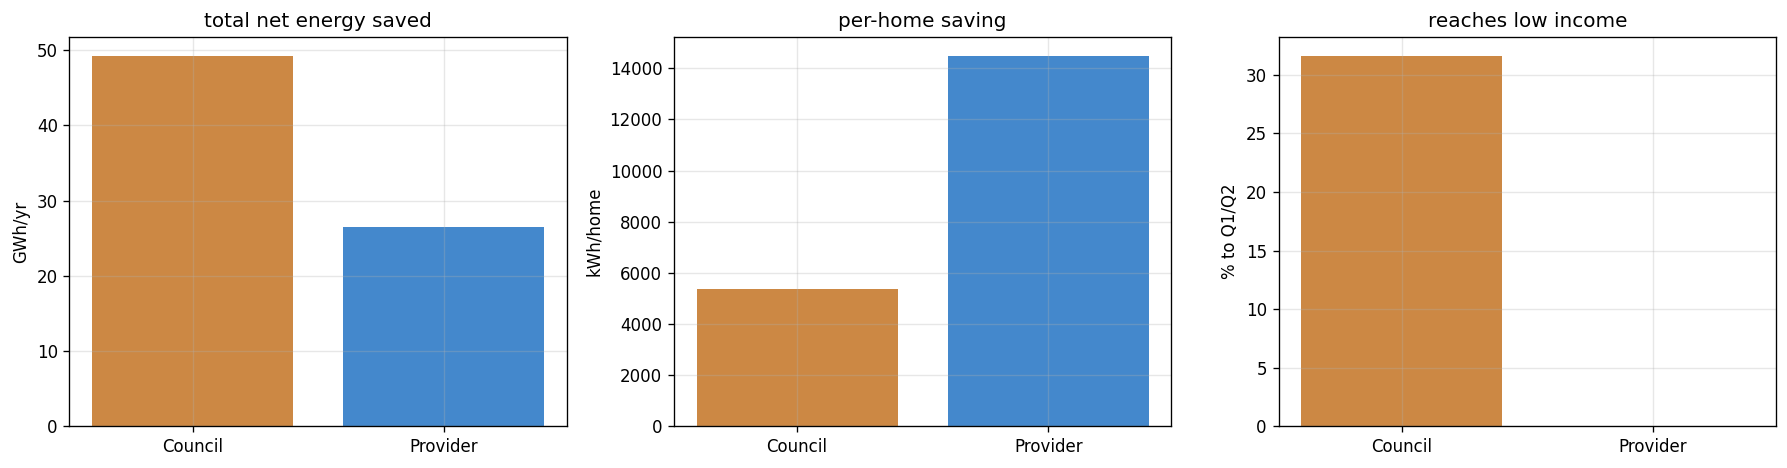

In [5]:
head = {n: impact(idx, hp_mult[HEAD]) for n, idx in cohorts.items()}
co = "Council / social rent"; pr = "Provider / grants (wealthy)"
print(f"{'':30s}{'homes':>8s}{'net GWh':>9s}{'per home':>10s}{'% to Q1/Q2':>11s}")
for n in cohorts:
    print(f"{n:30s}{head[n]['homes']:8,d}{head[n]['net_GWh']:9.1f}{head[n]['per_home_net_kwh']:10.0f}{100*head[n]['q12_savings_share']:11.0f}")
print(f"\nper home, grants save {head[pr]['per_home_net_kwh']/head[co]['per_home_net_kwh']:.1f} times the council route, but the council reaches {head[co]['homes']/max(head[pr]['homes'],1):.1f} times the homes,")
print(f"so on total energy delivered the council saves {head[co]['net_GWh']/max(head[pr]['net_GWh'],1e-9):.1f} times as much ({head[co]['net_GWh']:.0f} vs {head[pr]['net_GWh']:.0f} GWh/yr).")
print(f"equity: the council sends {100*head[co]['q12_savings_share']:.0f}% of savings to Q1/Q2 against {100*head[pr]['q12_savings_share']:.0f}% for grants.")

col = {co: "#c84", pr: "#48c"}; names = list(cohorts); x = np.arange(2); lab = [n.split(" / ")[0] for n in names]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].bar(x, [head[n]["net_GWh"] for n in names], color=[col[n] for n in names])
ax[0].set_xticks(x); ax[0].set_xticklabels(lab); ax[0].set(ylabel="GWh/yr", title="total net energy saved")
ax[1].bar(x, [head[n]["per_home_net_kwh"] for n in names], color=[col[n] for n in names])
ax[1].set_xticks(x); ax[1].set_xticklabels(lab); ax[1].set(ylabel="kWh/home", title="per-home saving")
ax[2].bar(x, [100*head[n]["q12_savings_share"] for n in names], color=[col[n] for n in names])
ax[2].set_xticks(x); ax[2].set_xticklabels(lab); ax[2].set(ylabel="% to Q1/Q2", title="reaches low income")
plt.tight_layout()
plt.show()

## 5 · Who is reached

The income and energy-rating composition of the treated homes under each route, which is
where the distributional difference shows up directly.

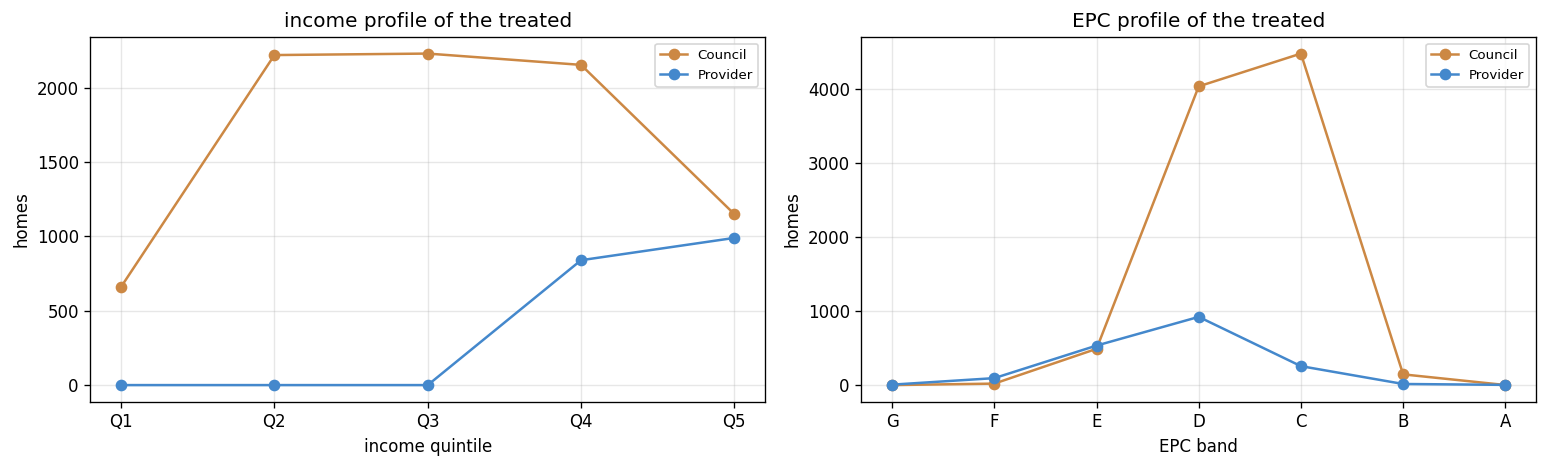

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4)); band = {1: "G", 2: "F", 3: "E", 4: "D", 5: "C", 6: "B", 7: "A"}
for n, idx in cohorts.items():
    c = elig.loc[idx]
    inc = c.hh_income_band.value_counts().reindex(["q1_lowest", "q2_low", "q3_mid", "q4_high", "q5_highest"]).fillna(0)
    ax[0].plot(["Q1", "Q2", "Q3", "Q4", "Q5"], inc.values, "-o", label=n.split(" / ")[0], color=col[n])
    ax[1].plot([band[b] for b in range(1, 8)], [(c.sap_band_ord == b).sum() for b in range(1, 8)], "-o",
               label=n.split(" / ")[0], color=col[n])
ax[0].set(xlabel="income quintile", ylabel="homes", title="income profile of the treated"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="EPC band", ylabel="homes", title="EPC profile of the treated"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6 · Translation to carbon and cost

Energy is the model output; carbon and cost are downstream translations. The BEIS 2023
factors are gas 0.183 and grid electricity 0.207 kgCO2/kWh, and the grid figure falls over
time, so the carbon saving is a present-day floor. The heat pump costs 12,000 gross, of
which the Boiler Upgrade Scheme grant covers 7,500, levelised over a 15-year life.

In [7]:
print(f"{'route':30s}{'net GWh':>9s}{'ktCO2/yr':>10s}{'cost/tCO2':>11s}")
for n, idx in cohorts.items():
    c = elig.loc[idx]; gh = c.gas_heat_kwh.sum()
    carbon = (gh*GAS_KGCO2 - gh*hp_mult[HEAD]*ELEC_KGCO2) / 1e6
    print(f"{n:30s}{head[n]['net_GWh']:9.1f}{carbon:10.2f}{len(c)*HP_COST/max(carbon*1e3*HP_LIFETIME,1e-9):11.0f}")

route                           net GWh  ktCO2/yr  cost/tCO2
Council / social rent              49.3      8.46        868
Provider / grants (wealthy)        26.5      4.55        322


## 7 · The governance finding

At each actor's realistic reach in Newcastle, calibrated to SERL demand and field
heat-pump performance:

- The provider grant route saves the most per home, because it reaches large, high-consuming
  homes, and it is cheapest per home. But its reach is throttled by voluntary uptake, and
  what it delivers is regressive, public subsidy to households who could largely self-fund.
- The council social-rent route saves less per home, but because it owns its stock it can
  convert many times more homes, so it delivers more total energy, and it is progressive,
  the savings reaching lower-income tenants.

The per-home efficiency advantage of grants is real but moot when uptake is the binding
constraint: the actor that can act at scale decarbonises more, and more fairly. The policy
choice is not the technology, nor even efficiency against equity; it is which institutional
actor can act, on whom, and how fast. Targeting logic is a governance variable, because the
route that runs the programme moves its total energy outcome, its distribution, and its
deliverability together. The provider's reach is set by `PROVIDER_UPTAKE`, and the headline
is robust across plausible uptake, since the council's owned-stock advantage dominates
unless grant uptake approaches the full eligible base.

All demand is the v7 calibrated model's own output, with no proxy fields and no re-fit.
Tenure and income come from the synthetic population, which covers about 70 per cent on
income, and unmatched homes are excluded from income targeting. The carbon and cost in
Section 6 are translations of the energy result. The winter electricity added has
grid-peak implications worth a forward-looking extension.